# SST-Chlorophyll DBSCAN Clustering (June 2010 - November 2011)

This notebook combines MUR L4 SST and MODIS L2 chlorophyll data, projects them onto a common grid, and performs DBSCAN clustering to identify oceanic regimes.

**Pipeline:**
1. Load SST data (MUR L4) and chlorophyll data (MODIS L2)
2. Project both onto a common lat/lon grid
3. Prepare feature vectors (SST, chlorophyll) for pixels with both measurements
4. Apply DBSCAN clustering
5. Visualize clusters on a map
6. Save processed data to E:\satdata\Custom

## 1. Setup and Imports

In [31]:
# Essential imports
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy.stats import binned_statistic_2d
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import pickle
import cmocean

import sys
sys.dont_write_bytecode = True
sys.path.append(os.path.abspath(".."))

from pipelines.l3_pipeline import L3DatasetLoader
from pipelines.l2_pipeline import L2DatasetLoader, GPUDataExtractor

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configuration

In [32]:
# Geographical bounds - Texas Louisiana Shelf
lon_min, lon_max = -94.0, -88.0
lat_min, lat_max = 27.5, 30.5

# Grid resolution
lat_bins = 200
lon_bins = 300

# Data paths - separate folders for each year
sst_base_pattern = r"E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
chlor_base_pattern = r"E:\satdata\Texas Louisiana Shelf_{year}-06-01_{year}-11-30"
output_dir = r"E:\satdata\Custom"

# Variables
sst_var = 'analysed_sst'
chlor_var = 'chlor_a'
chlor_group = 'geophysical_data'

# DBSCAN parameters
eps = 0.3  # Maximum distance between samples
min_samples = 4  # Minimum samples in a neighborhood to form a cluster

# Years
years = [2010, 2011]

print(f"Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")
print(f"Grid: {lat_bins} x {lon_bins} bins")
print(f"Output directory: {output_dir}")
print(f"DBSCAN eps: {eps}, min_samples: {min_samples}")
print(f"Years: {years}")

Region: [-94.0, 27.5] to [-88.0, 30.5]
Grid: 200 x 300 bins
Output directory: E:\satdata\Custom
DBSCAN eps: 0.3, min_samples: 4
Years: [2010, 2011]


## 3. Load SST Data (MUR L4)

In [33]:
# Find SST files from both years
sst_files = []
for year in years:
    sst_dir = sst_base_pattern.format(year=year)
    year_files = glob.glob(os.path.join(sst_dir, '*.nc'))
    sst_files.extend(year_files)
    print(f"Year {year}: Found {len(year_files)} SST files in {sst_dir}")

sst_files = sorted(sst_files)

if not sst_files:
    raise FileNotFoundError(f"No SST files found. Check directories for years {years}")
else:
    print(f"\nTotal: Found {len(sst_files)} SST files")

# Load SST datasets
sst_loader = L3DatasetLoader(variables=[sst_var], bbox=(lon_min, lon_max, lat_min, lat_max))

if sst_files:
    try:
        sst_datasets = sst_loader.load_multiple(sst_files)
        print(f"Successfully loaded {len(sst_datasets)} SST datasets")
        
        if not sst_datasets:
            raise ValueError("No datasets were successfully loaded. Check file paths and variable names.")
        
        # Get lat/lon from first dataset (MUR L4 has consistent grid for all days)
        lat_sst = sst_datasets[0]['lat'].values
        lon_sst = sst_datasets[0]['lon'].values
        print(f"SST grid: lat {lat_sst.shape}, lon {lon_sst.shape}")
        
        # Verify grid consistency (optional check)
        if len(sst_datasets) > 1:
            lat_check = sst_datasets[-1]['lat'].values
            lon_check = sst_datasets[-1]['lon'].values
            if np.array_equal(lat_sst, lat_check) and np.array_equal(lon_sst, lon_check):
                print("✓ Grid consistency verified (first and last file match)")
            else:
                print("⚠ Warning: Grid mismatch detected!")
        
        # Extract and process SST data, then average
        sst_list = []
        for i, ds in enumerate(sst_datasets):
            sst_kelvin = ds[sst_var].values.squeeze()  # Remove time dimension
            sst_celsius = sst_kelvin - 273.15
            # Quality control
            sst_celsius[(sst_celsius < -2) | (sst_celsius > 35)] = np.nan
            sst_list.append(sst_celsius)
            
            if i % 100 == 0:
                print(f"Processed {i+1}/{len(sst_datasets)} SST files...")
        
        # Average all SST data (temporal mean)
        sst_stack = np.stack(sst_list, axis=0)
        sst_mean = np.nanmean(sst_stack, axis=0)
        
        print(f"\nSST grid shape: {sst_mean.shape}")
        print(f"SST range: {np.nanmin(sst_mean):.2f} to {np.nanmax(sst_mean):.2f} °C")
        print(f"Valid SST pixels: {np.sum(~np.isnan(sst_mean))}")
        
    except Exception as e:
        print(f"Error loading SST datasets: {e}")
        raise
else:
    raise FileNotFoundError("No SST files found to load")

Year 2010: Found 184 SST files in E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_2010-06-01_2010-11-30
Year 2011: Found 184 SST files in E:\satdata\MUR-JPL-L4-GLOB-v4.1_Texas Louisiana Shelf_2011-06-01_2011-11-30

Total: Found 368 SST files
Successfully loaded 368 SST datasets
SST grid: lat (301,), lon (601,)
✓ Grid consistency verified (first and last file match)
Processed 1/368 SST files...
Successfully loaded 368 SST datasets
SST grid: lat (301,), lon (601,)
✓ Grid consistency verified (first and last file match)
Processed 1/368 SST files...
Processed 101/368 SST files...
Processed 101/368 SST files...
Processed 201/368 SST files...
Processed 201/368 SST files...
Processed 301/368 SST files...
Processed 301/368 SST files...

SST grid shape: (301, 601)
SST range: 26.67 to 28.71 °C
Valid SST pixels: 137002

SST grid shape: (301, 601)
SST range: 26.67 to 28.71 °C
Valid SST pixels: 137002


## 4. Load Chlorophyll Data (MODIS L2)

In [34]:
# Find chlorophyll files
chlor_files = []
for year in years:
    chlor_dir = chlor_base_pattern.format(year=year)
    year_files = glob.glob(os.path.join(chlor_dir, '**', '*.nc'), recursive=True)
    chlor_files.extend(year_files)

print(f"Found {len(chlor_files)} chlorophyll files")

# Limit for testing (remove for full processing)
# chlor_files = chlor_files[:50]
# print(f"Using {len(chlor_files)} files for processing")

# Load chlorophyll datasets
chlor_loader = L2DatasetLoader(variables=[chlor_var], group=chlor_group)
chlor_datasets = chlor_loader.load_multiple(chlor_files)
print(f"Loaded {len(chlor_datasets)} chlorophyll datasets")

Found 586 chlorophyll files
Loaded 586 chlorophyll datasets
Loaded 586 chlorophyll datasets


In [35]:
# Extract chlorophyll data
try:
    print("Attempting GPU extraction...")
    extractor = GPUDataExtractor(variables=[chlor_var])
    lon_chlor_flat, lat_chlor_flat, chlor_data = extractor.extract(chlor_datasets)
    chlor_flat = chlor_data[chlor_var]
    print(f"✓ GPU extraction: {len(chlor_flat)} points")
except Exception as e:
    print(f"GPU failed: {e}. Using CPU...")
    all_lons, all_lats, all_chlor = [], [], []
    for i, ds in enumerate(chlor_datasets):
        if i % 50 == 0:
            print(f"Processing {i+1}/{len(chlor_datasets)}...")
        lat = ds['lat'].values.flatten()
        lon = ds['lon'].values.flatten()
        chlor = ds[chlor_var].values.flatten()
        valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
        all_lats.extend(lat[valid])
        all_lons.extend(lon[valid])
        all_chlor.extend(chlor[valid])
    lat_chlor_flat = np.array(all_lats)
    lon_chlor_flat = np.array(all_lons)
    chlor_flat = np.array(all_chlor)
    print(f"✓ CPU extraction: {len(chlor_flat)} points")

print(f"Chlorophyll range: {np.min(chlor_flat):.6f} to {np.max(chlor_flat):.6f} mg/m³")

Attempting GPU extraction...
✓ GPU extraction: 234776489 points
Chlorophyll range: 0.001000 to 86.378639 mg/m³
✓ GPU extraction: 234776489 points
Chlorophyll range: 0.001000 to 86.378639 mg/m³


## 5. Project Chlorophyll onto Common Grid

In [36]:
# Clip chlorophyll to bounding box
clip_mask = ((lon_chlor_flat >= lon_min) & (lon_chlor_flat <= lon_max) &
             (lat_chlor_flat >= lat_min) & (lat_chlor_flat <= lat_max))

lon_clipped = lon_chlor_flat[clip_mask]
lat_clipped = lat_chlor_flat[clip_mask]
chlor_clipped = chlor_flat[clip_mask]

print(f"Chlorophyll points in region: {len(chlor_clipped)}")

# Bin chlorophyll onto grid
chlor_binned, lat_edges, lon_edges, _ = binned_statistic_2d(
    lat_clipped, lon_clipped, chlor_clipped,
    statistic='mean',
    bins=[lat_bins, lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

print(f"Chlorophyll grid shape: {chlor_binned.shape}")
print(f"Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_binned))}")

Chlorophyll points in region: 12630754
Chlorophyll grid shape: (200, 300)
Valid chlorophyll pixels: 46406
Chlorophyll grid shape: (200, 300)
Valid chlorophyll pixels: 46406


## 6. Align SST to Chlorophyll Grid

In [37]:
# Resample SST to match chlorophyll grid
from scipy.interpolate import RegularGridInterpolator

# Create interpolator for SST
sst_interpolator = RegularGridInterpolator(
    (lat_sst, lon_sst), 
    sst_mean,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)

# Create target grid (bin centers)
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
lon_grid, lat_grid = np.meshgrid(lon_centers, lat_centers)

# Interpolate SST to chlorophyll grid
points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
sst_regridded = sst_interpolator(points).reshape(chlor_binned.shape)

print(f"Regridded SST shape: {sst_regridded.shape}")
print(f"Valid SST pixels after regridding: {np.sum(~np.isnan(sst_regridded))}")
print(f"SST range: {np.nanmin(sst_regridded):.2f} to {np.nanmax(sst_regridded):.2f} °C")

Regridded SST shape: (200, 300)
Valid SST pixels after regridding: 44898
SST range: 26.68 to 28.71 °C


## 7. Prepare Data for Clustering

In [38]:
# Create mask for pixels with both SST and chlorophyll
valid_mask = ~np.isnan(sst_regridded) & ~np.isnan(chlor_binned)
n_valid = np.sum(valid_mask)

print(f"Pixels with both SST and chlorophyll: {n_valid}")

# Extract valid pixels
sst_valid = sst_regridded[valid_mask]
chlor_valid = chlor_binned[valid_mask]

# Create feature matrix (N x 2)
features = np.column_stack([sst_valid, np.log10(chlor_valid)])  # Log-transform chlorophyll

print(f"Feature matrix shape: {features.shape}")
print(f"SST mean: {sst_valid.mean():.2f} °C, std: {sst_valid.std():.2f}")
print(f"Chlorophyll mean: {chlor_valid.mean():.6f} mg/m³, std: {chlor_valid.std():.6f}")

# Standardize features for DBSCAN
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"\nScaled features shape: {features_scaled.shape}")
print(f"Feature 0 (SST) mean: {features_scaled[:, 0].mean():.4f}, std: {features_scaled[:, 0].std():.4f}")
print(f"Feature 1 (log10 Chlor) mean: {features_scaled[:, 1].mean():.4f}, std: {features_scaled[:, 1].std():.4f}")

Pixels with both SST and chlorophyll: 44680
Feature matrix shape: (44680, 2)
SST mean: 28.15 °C, std: 0.49
Chlorophyll mean: 3.390938 mg/m³, std: 5.147958

Scaled features shape: (44680, 2)
Feature 0 (SST) mean: 0.0000, std: 1.0000
Feature 1 (log10 Chlor) mean: 0.0000, std: 1.0000


FINDING OPTIMAL EPSILON

Computing 4-nearest neighbor distances...

k-distance percentiles:
  50th percentile: 0.0071
  70th percentile: 0.0103
  80th percentile: 0.0127
  90th percentile: 0.0165
  95th percentile: 0.0205
  99th percentile: 0.0342

Running parameter sweep...


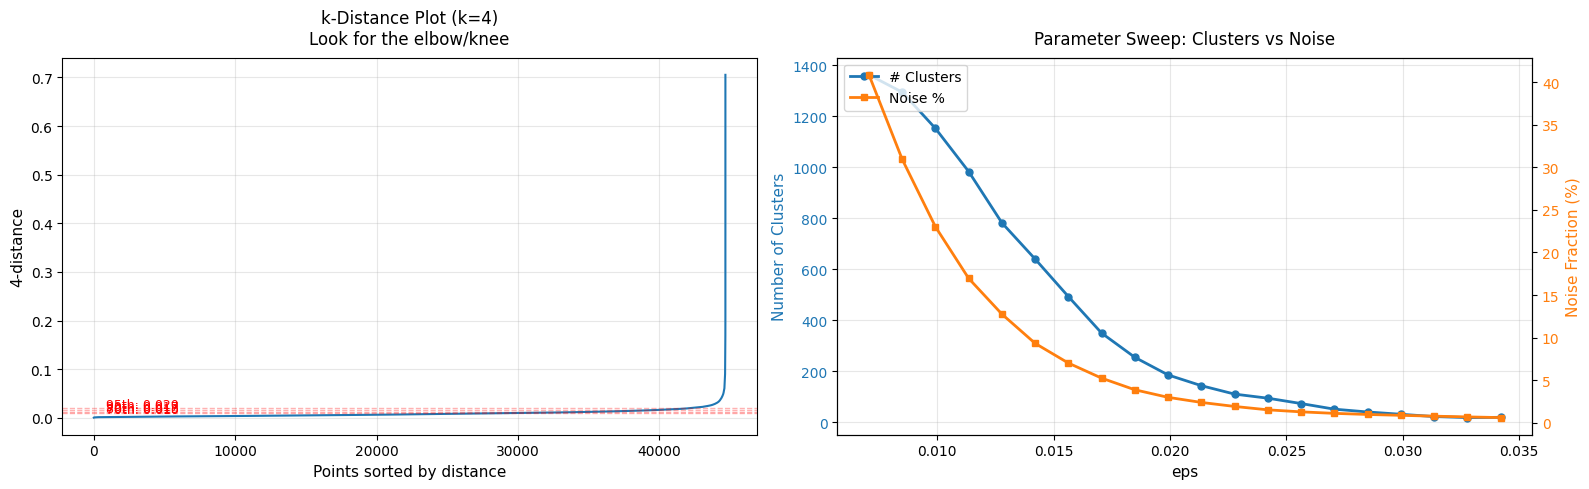


Parameter sweep results:
     eps   clusters      noise   noise_frac
--------------------------------------------
  0.0071       1362      18266        40.9%
  0.0099       1152      10285        23.0%
  0.0128        782       5698        12.8%
  0.0156        493       3127         7.0%
  0.0185        255       1724         3.9%
  0.0213        144       1060         2.4%
  0.0242         95        671         1.5%
  0.0271         52        486         1.1%
  0.0299         32        383         0.9%
  0.0328         19        300         0.7%

OPTIMAL PARAMETERS SELECTED
  eps: 0.0142
  min_samples: 4
  Expected clusters: 640
  Expected noise: 4161 (9.3%)

✓ Updated eps = 0.0142


In [39]:
from sklearn.neighbors import NearestNeighbors

# Compute k-distance plot (k = min_samples)
print("=" * 60)
print("FINDING OPTIMAL EPSILON")
print("=" * 60)

k = min_samples
print(f"\nComputing {k}-nearest neighbor distances...")
nbrs = NearestNeighbors(n_neighbors=k).fit(features_scaled)
distances, _ = nbrs.kneighbors(features_scaled)
k_dist = np.sort(distances[:, -1])  # distance to k-th nearest neighbor

# Plot k-distance curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_dist, linewidth=1.5, color='#1f77b4')
axes[0].set_xlabel('Points sorted by distance', fontsize=11)
axes[0].set_ylabel(f'{k}-distance', fontsize=11)
axes[0].set_title(f'k-Distance Plot (k={k})\nLook for the elbow/knee', fontsize=12, pad=10)
axes[0].grid(True, alpha=0.3)

# Highlight candidate eps region (elbow typically in 70-95 percentile range)
percentiles = [70, 80, 90, 95]
for p in percentiles:
    val = np.percentile(k_dist, p)
    axes[0].axhline(val, color='red', linestyle='--', alpha=0.3, linewidth=1)
    axes[0].text(len(k_dist)*0.02, val, f'{p}th: {val:.3f}', fontsize=9, color='red')

print(f"\nk-distance percentiles:")
for p in [50, 70, 80, 90, 95, 99]:
    print(f"  {p}th percentile: {np.percentile(k_dist, p):.4f}")

# Parameter sweep to find optimal eps
print(f"\nRunning parameter sweep...")
eps_min = np.percentile(k_dist, 50)
eps_max = np.percentile(k_dist, 99)
eps_values = np.linspace(eps_min, eps_max, 20)

sweep_results = []
for e in eps_values:
    db = DBSCAN(eps=e, min_samples=min_samples, n_jobs=-1).fit(features_scaled)
    labels_temp = db.labels_
    n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
    n_noise_temp = np.sum(labels_temp == -1)
    noise_frac = n_noise_temp / len(labels_temp)
    sweep_results.append((e, n_clusters_temp, n_noise_temp, noise_frac))

# Plot sweep results
eps_arr = np.array([r[0] for r in sweep_results])
n_clusters_arr = np.array([r[1] for r in sweep_results])
noise_frac_arr = np.array([r[3] for r in sweep_results])

ax2 = axes[1]
ax2_twin = ax2.twinx()

# Plot clusters
line1 = ax2.plot(eps_arr, n_clusters_arr, 'o-', color='#1f77b4', 
                 label='# Clusters', linewidth=2, markersize=5)
ax2.set_xlabel('eps', fontsize=11)
ax2.set_ylabel('Number of Clusters', fontsize=11, color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.grid(True, alpha=0.3)

# Plot noise fraction
line2 = ax2_twin.plot(eps_arr, noise_frac_arr * 100, 's-', color='#ff7f0e', 
                      label='Noise %', linewidth=2, markersize=5)
ax2_twin.set_ylabel('Noise Fraction (%)', fontsize=11, color='#ff7f0e')
ax2_twin.tick_params(axis='y', labelcolor='#ff7f0e')

ax2.set_title('Parameter Sweep: Clusters vs Noise', fontsize=12, pad=10)

# Combine legends
lines = line1 + line2
labels_legend = [l.get_label() for l in lines]
ax2.legend(lines, labels_legend, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Print sweep summary
print(f"\nParameter sweep results:")
print(f"{'eps':>8s} {'clusters':>10s} {'noise':>10s} {'noise_frac':>12s}")
print("-" * 44)
for e, nc, nn, nf in sweep_results[::2]:  # print every other result
    print(f"{e:8.4f} {nc:10d} {nn:10d} {nf:12.1%}")

# Select optimal eps: balance between cluster count stability and low noise
# Strategy: find eps where clusters stabilize (derivative is small) and noise < 15%
cluster_diff = np.abs(np.diff(n_clusters_arr))
stable_mask = (cluster_diff < 1) if len(cluster_diff) > 0 else np.ones(len(n_clusters_arr) - 1, dtype=bool)
stable_mask = np.append(stable_mask, True)  # include last point
low_noise_mask = noise_frac_arr < 0.15

# Find candidates: stable clusters + low noise + reasonable cluster count
candidate_mask = stable_mask & low_noise_mask & (n_clusters_arr >= 2) & (n_clusters_arr <= 10)

if np.any(candidate_mask):
    # Pick the one with lowest noise among candidates
    candidate_idx = np.where(candidate_mask)[0]
    best_idx = candidate_idx[np.argmin(noise_frac_arr[candidate_idx])]
else:
    # Fallback: pick eps at 85th percentile of k-distance
    best_idx = np.argmin(np.abs(eps_arr - np.percentile(k_dist, 85)))

optimal_eps = sweep_results[best_idx][0]
optimal_n_clusters = sweep_results[best_idx][1]
optimal_noise = sweep_results[best_idx][2]
optimal_noise_frac = sweep_results[best_idx][3]

print(f"\n" + "=" * 60)
print(f"OPTIMAL PARAMETERS SELECTED")
print("=" * 60)
print(f"  eps: {optimal_eps:.4f}")
print(f"  min_samples: {min_samples}")
print(f"  Expected clusters: {optimal_n_clusters}")
print(f"  Expected noise: {optimal_noise} ({optimal_noise_frac:.1%})")
print("=" * 60)

# Update eps for subsequent cells
eps = optimal_eps
print(f"\n✓ Updated eps = {eps:.4f}")

## 7b. Find Optimal Epsilon (k-distance plot + sweep)

## 8. DBSCAN Clustering (with optimal eps)

In [40]:
# Apply DBSCAN clustering with optimal eps
print("=" * 60)
print("DBSCAN CLUSTERING (OPTIMAL PARAMETERS)")
print("=" * 60)
print(f"eps = {eps:.4f}, min_samples = {min_samples}")

dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean', n_jobs=-1)
labels = dbscan.fit_predict(features_scaled)

print(f"\n✓ Clustering complete")

# Analyze results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"\nNumber of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({100*n_noise/len(labels):.1f}%)")

# Cluster statistics
print(f"\nPixels per cluster:")
unique_labels = sorted(set(labels))
for label in unique_labels:
    count = np.sum(labels == label)
    if label == -1:
        print(f"  Noise (-1): {count} pixels ({100*count/n_valid:.1f}%)")
    else:
        print(f"  Cluster {label}: {count} pixels ({100*count/n_valid:.1f}%)")

# Compute cluster centers (excluding noise)
print(f"\nCluster centers (original scale):")
for label in unique_labels:
    if label == -1:
        continue
    mask = labels == label
    sst_cluster = sst_valid[mask]
    chlor_cluster = chlor_valid[mask]
    print(f"  Cluster {label}: SST={sst_cluster.mean():.2f}°C, Chlor={chlor_cluster.mean():.6f} mg/m³")

DBSCAN CLUSTERING (OPTIMAL PARAMETERS)
eps = 0.0142, min_samples = 4

✓ Clustering complete

Number of clusters found: 640
Number of noise points: 4161 (9.3%)

Pixels per cluster:
  Noise (-1): 4161 pixels (9.3%)
  Cluster 0: 32786 pixels (73.4%)
  Cluster 1: 3 pixels (0.0%)
  Cluster 2: 4 pixels (0.0%)
  Cluster 3: 8 pixels (0.0%)
  Cluster 4: 5 pixels (0.0%)
  Cluster 5: 15 pixels (0.0%)
  Cluster 6: 6 pixels (0.0%)
  Cluster 7: 9 pixels (0.0%)
  Cluster 8: 7 pixels (0.0%)
  Cluster 9: 6 pixels (0.0%)
  Cluster 10: 6 pixels (0.0%)
  Cluster 11: 10 pixels (0.0%)
  Cluster 12: 10 pixels (0.0%)
  Cluster 13: 8 pixels (0.0%)
  Cluster 14: 8 pixels (0.0%)
  Cluster 15: 13 pixels (0.0%)
  Cluster 16: 5 pixels (0.0%)
  Cluster 17: 4 pixels (0.0%)
  Cluster 18: 9 pixels (0.0%)
  Cluster 19: 11 pixels (0.0%)
  Cluster 20: 9 pixels (0.0%)
  Cluster 21: 4 pixels (0.0%)
  Cluster 22: 39 pixels (0.1%)
  Cluster 23: 7 pixels (0.0%)
  Cluster 24: 4 pixels (0.0%)
  Cluster 25: 6 pixels (0.0%)
  Clus

## 9. Visualize DBSCAN Results

In [49]:
# Create cluster map
cluster_map = np.full(sst_regridded.shape, np.nan)
cluster_map[valid_mask] = labels

# Define a nicer discrete colormap: blue, orange, green and gray for noise
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex

unique_labels = sorted(set(labels))
cluster_labels = [l for l in unique_labels if l != -1]
cluster_labels_sorted = sorted(cluster_labels)

# Choose palette (blue, orange, green) and gray for noise
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']  # matplotlib default blue, orange, green
# If there are more clusters than palette entries, extend with viridis
if len(cluster_labels_sorted) > len(palette):
    extra = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted) - len(palette)))
    extra_hex = [rgb2hex(c) for c in extra]
    palette = palette + extra_hex

# Build full colormap with noise at index 0 (we'll map -1 to 0)
cmap_colors = ['#808080'] + palette  # gray first
cmap = ListedColormap(cmap_colors)

# Prepare an array for plotting where noise -> 0 and clusters -> 1..N
plot_map = np.full_like(cluster_map, np.nan)
plot_map[valid_mask] = np.where(labels == -1, 0, np.array([cluster_labels_sorted.index(l) + 1 for l in labels[valid_mask]]))

# Set up norm and ticks
bounds = np.arange(0, len(cluster_labels_sorted) + 2) - 0.5
norm = BoundaryNorm(bounds, cmap.N)

# Plot clusters on map
fig, ax = plt.subplots(1, 1, figsize=(14, 10), 
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

cluster_plot = ax.pcolormesh(
    lon_edges, lat_edges, plot_map,
    cmap=cmap, norm=norm, shading='auto',
    transform=ccrs.PlateCarree()
)

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Colorbar
cbar = plt.colorbar(cluster_plot, ax=ax, boundaries=bounds, ticks=np.arange(0, len(cluster_labels_sorted) + 1))
# Build tick labels: 'Noise' then Cluster IDs
tick_labels = ['Noise'] + [f'Cluster {l}' for l in cluster_labels_sorted]
cbar.set_ticklabels(tick_labels)

ax.set_title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})\n' + 
             f'Texas-Louisiana Shelf (June 2010 - November 2011)\n' +
             f'{n_clusters} clusters, {n_noise} noise points', 
             fontsize=13, pad=10)

plt.tight_layout()
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

## 10. Feature Space Visualization

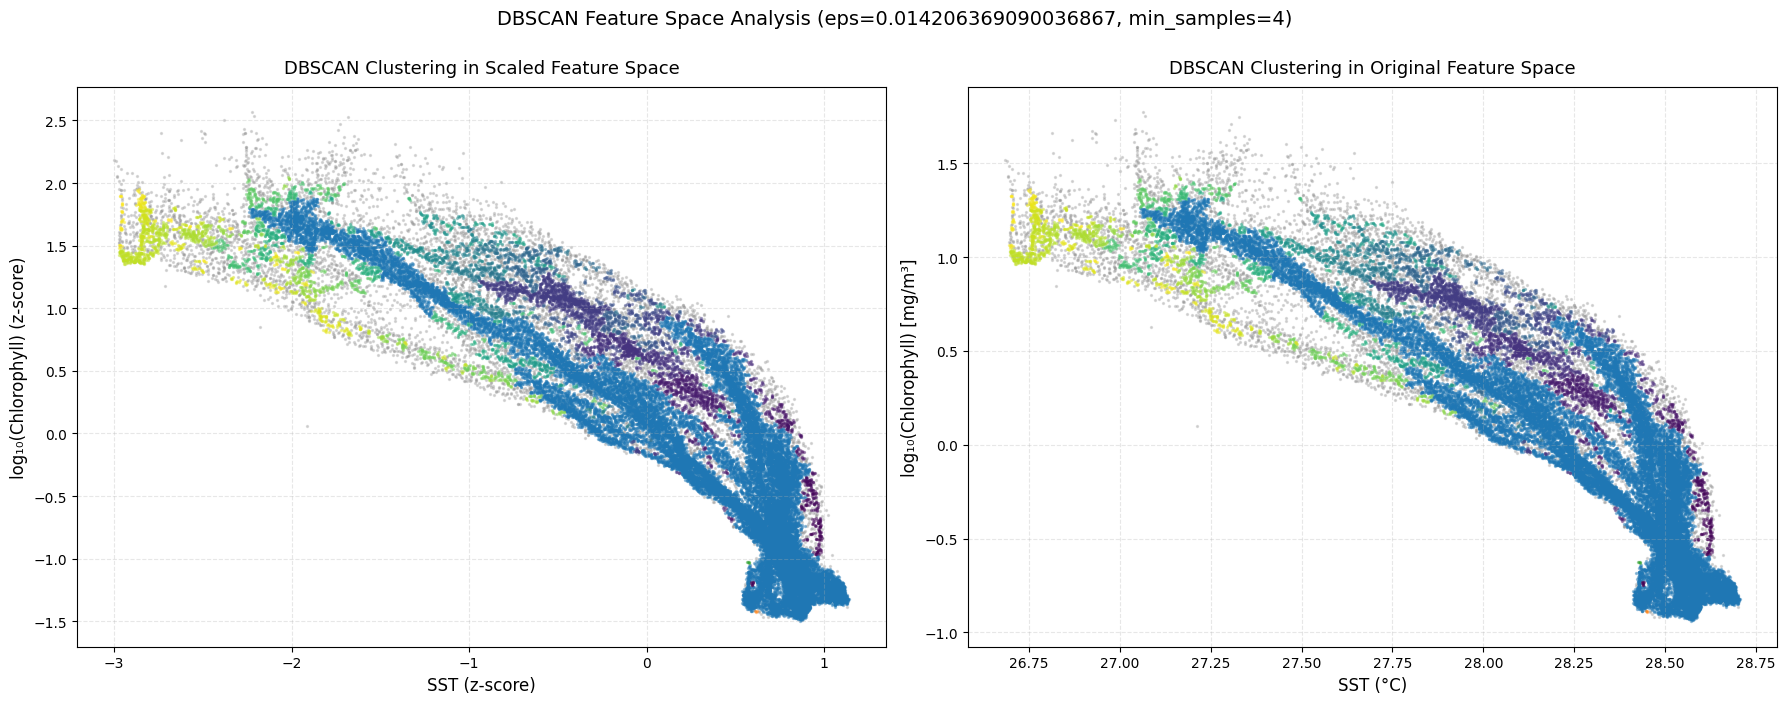

In [48]:
# Feature space scatter plot
from matplotlib.colors import rgb2hex

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Generate colors for clusters: noise gray + blue, orange, green
unique_labels = sorted(set(labels))
cluster_labels = [l for l in unique_labels if l != -1]
cluster_labels_sorted = sorted(cluster_labels)

palette = ['#1f77b4', '#ff7f0e', '#2ca02c']
if len(cluster_labels_sorted) > len(palette):
    extra = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted) - len(palette)))
    extra_hex = [rgb2hex(c) for c in extra]
    palette = palette + extra_hex

colors_map = { -1: '#808080' }
for i, cl in enumerate(cluster_labels_sorted):
    colors_map[cl] = palette[i]

# Left plot: Scaled features
for cl in unique_labels:
    mask = labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[0].scatter(features_scaled[mask, 0], features_scaled[mask, 1], 
                    alpha=0.4 if cl != -1 else 0.25, s=2, color=color, label=label_text)

axes[0].set_xlabel('SST (z-score)', fontsize=12)
axes[0].set_ylabel('log₁₀(Chlorophyll) (z-score)', fontsize=12)
axes[0].set_title('DBSCAN Clustering in Scaled Feature Space', fontsize=13, pad=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Right plot: Original features
for cl in unique_labels:
    mask = labels == cl
    color = colors_map.get(cl, '#000000')
    label_text = 'Noise' if cl == -1 else f'Cluster {cl}'
    axes[1].scatter(sst_valid[mask], np.log10(chlor_valid[mask]), 
                    alpha=0.4 if cl != -1 else 0.25, s=2, color=color, label=label_text)

axes[1].set_xlabel('SST (°C)', fontsize=12)
axes[1].set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=12)
axes[1].set_title('DBSCAN Clustering in Original Feature Space', fontsize=13, pad=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle(f'DBSCAN Feature Space Analysis (eps={eps}, min_samples={min_samples})', 
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 11. Detailed Cluster Statistics

In [ ]:
print("=" * 80)
print("DETAILED CLUSTER CHARACTERISTICS")
print("=" * 80)

for label in sorted(set(labels)):
    mask = labels == label
    sst_cluster = sst_valid[mask]
    chlor_cluster = chlor_valid[mask]
    
    if label == -1:
        print(f"\n⚪ Noise Points:")
    else:
        print(f"\n🔵 Cluster {label}:")
    
    print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"  SST: {sst_cluster.mean():.2f} ± {sst_cluster.std():.2f} °C")
    print(f"       Range: [{sst_cluster.min():.2f}, {sst_cluster.max():.2f}] °C")
    print(f"  Chlorophyll: {chlor_cluster.mean():.6f} ± {chlor_cluster.std():.6f} mg/m³")
    print(f"               Range: [{chlor_cluster.min():.6f}, {chlor_cluster.max():.6f}] mg/m³")

print("\n" + "=" * 80)

DETAILED CLUSTER CHARACTERISTICS

⚪ Noise Points:
  Pixels: 2 (0.0%)
  SST: 27.01 ± 0.20 °C
       Range: [26.81, 27.21] °C
  Chlorophyll: 23.535900 ± 22.283619 mg/m³
               Range: [1.252281, 45.819518] mg/m³

🔵 Cluster 0:
  Pixels: 44,678 (100.0%)
  SST: 28.15 ± 0.49 °C
       Range: [26.68, 28.71] °C
  Chlorophyll: 3.390036 ± 5.144148 mg/m³
               Range: [0.114499, 59.115369] mg/m³



## 12. Save Results

In [ ]:
# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Save results as pickle
results = {
    'sst_grid': sst_regridded,
    'chlor_grid': chlor_binned,
    'cluster_map': cluster_map,
    'cluster_labels': labels,
    'dbscan_model': dbscan,
    'scaler': scaler,
    'lat_centers': lat_centers,
    'lon_centers': lon_centers,
    'lat_edges': lat_edges,
    'lon_edges': lon_edges,
    'valid_mask': valid_mask,
    'n_clusters': n_clusters,
    'n_noise': n_noise,
    'eps': eps,
    'min_samples': min_samples,
    'bbox': (lon_min, lon_max, lat_min, lat_max)
}

output_file = os.path.join(output_dir, 'sst_chlorophyll_dbscan_2010_2011.pkl')
with open(output_file, 'wb') as f:
    pickle.dump(results, f)

print(f"✓ Results saved to: {output_file}")
print(f"File size: {os.path.getsize(output_file) / 1e6:.2f} MB")

✓ Results saved to: E:\satdata\Custom\sst_chlorophyll_dbscan_2010_2011.pkl
File size: 2.93 MB


## 13. Example: Apply Clusters to Specific Time Period (May 17 - June 1, 2011)

In [53]:
# Load data for May 17 - June 1, 2011
import pandas as pd

example_start = '2011-08-15'
example_end = '2011-09-15'

print(f"Loading data for {example_start} to {example_end}")

# Find all SST files for 2011
sst_example_dir = sst_base_pattern.format(year=2011)
all_sst_files_2011 = sorted(glob.glob(os.path.join(sst_example_dir, '*.nc')))
print(f"Total SST files in 2011: {len(all_sst_files_2011)}")

# Filter files by time coordinate (MUR L4 approach)
sst_example_files = []
for sst_file in all_sst_files_2011:
    try:
        with xr.open_dataset(sst_file) as ds:
            file_time = pd.to_datetime(ds.time.values[0])
            if pd.Timestamp(example_start) <= file_time <= pd.Timestamp(example_end):
                sst_example_files.append(sst_file)
    except Exception as e:
        continue

print(f"Found {len(sst_example_files)} SST files for the period {example_start} to {example_end}")

# Load SST datasets using L3 loader
sst_example_datasets = sst_loader.load_multiple(sst_example_files)
print(f"Loaded {len(sst_example_datasets)} SST datasets")

# Process and average SST
sst_example_list = []
for ds in sst_example_datasets:
    sst_k = ds[sst_var].values.squeeze()
    sst_c = sst_k - 273.15
    sst_c[(sst_c < -2) | (sst_c > 35)] = np.nan
    sst_example_list.append(sst_c)

sst_example_mean = np.nanmean(np.stack(sst_example_list, axis=0), axis=0)
print(f"SST range: {np.nanmin(sst_example_mean):.2f} to {np.nanmax(sst_example_mean):.2f} °C")

Loading data for 2011-08-15 to 2011-09-15
Total SST files in 2011: 184
Found 31 SST files for the period 2011-08-15 to 2011-09-15
Loaded 31 SST datasets
SST range: 29.15 to 30.72 °C


In [57]:
# Find chlorophyll files for this period
chlor_example_dir = chlor_base_pattern.format(year=2011)
all_chlor_files_2011 = glob.glob(os.path.join(chlor_example_dir, '**', '*.nc'), recursive=True)
print(f"Total chlorophyll files in 2011: {len(all_chlor_files_2011)}")

# Filter files by parsing filename (MODIS L2 standard approach)
# MODIS L2 filename format: AQUA_MODIS.YYYYMMDDTHHMMSS...
chlor_example_files = []
for chlor_file in all_chlor_files_2011:
    filename = os.path.basename(chlor_file)
    try:
        # Check if it's a MODIS file
        if 'AQUA_MODIS' in filename or 'MODIS' in filename:
            parts = filename.split('.')
            if len(parts) > 1:
                # Extract date from second part (YYYYMMDDTHHMMSS)
                date_str = parts[1][:8]  # YYYYMMDD
                file_date = pd.to_datetime(date_str, format='%Y%m%d')
                
                # Check if file is within date range
                if pd.Timestamp(example_start) <= file_date <= pd.Timestamp(example_end):
                    chlor_example_files.append(chlor_file)
    except Exception as e:
        # Skip files that don't match expected format
        continue

print(f"Found {len(chlor_example_files)} chlorophyll files for the period {example_start} to {example_end}")

# Debug: Show a few example filenames if no files found
if len(chlor_example_files) == 0 and len(all_chlor_files_2011) > 0:
    print(f"\nDebug - Example filenames (first 3):")
    for i, f in enumerate(all_chlor_files_2011[:3]):
        print(f"  {os.path.basename(f)}")
    print(f"\nLooking for dates between {example_start} and {example_end}")

# Only proceed with loading if files were found
if len(chlor_example_files) > 0:
    # Load chlorophyll datasets using L2 loader
    chlor_example_datasets = chlor_loader.load_multiple(chlor_example_files)
    print(f"Loaded {len(chlor_example_datasets)} chlorophyll datasets")
    
    # Extract chlorophyll data
    try:
        print("Extracting chlorophyll data (GPU)...")
        extractor_ex = GPUDataExtractor(variables=[chlor_var])
        lon_chlor_ex, lat_chlor_ex, chlor_data_ex = extractor_ex.extract(chlor_example_datasets)
        chlor_ex = chlor_data_ex[chlor_var]
        print(f"✓ GPU extraction: {len(chlor_ex)} points")
    except Exception as e:
        print(f"GPU failed: {e}. Using CPU...")
        all_lons_ex, all_lats_ex, all_chlor_ex = [], [], []
        for i, ds in enumerate(chlor_example_datasets):
            lat = ds['lat'].values.flatten()
            lon = ds['lon'].values.flatten()
            chlor = ds[chlor_var].values.flatten()
            valid = (~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(chlor) & (chlor > 0))
            all_lats_ex.extend(lat[valid])
            all_lons_ex.extend(lon[valid])
            all_chlor_ex.extend(chlor[valid])
        lat_chlor_ex = np.array(all_lats_ex)
        lon_chlor_ex = np.array(all_lons_ex)
        chlor_ex = np.array(all_chlor_ex)
        print(f"✓ CPU extraction: {len(chlor_ex)} points")
else:
    print("⚠ No chlorophyll files found for this period. Skipping chlorophyll processing.")
    chlor_example_datasets = []
    lon_chlor_ex = np.array([])
    lat_chlor_ex = np.array([])
    chlor_ex = np.array([])

Total chlorophyll files in 2011: 296
Found 52 chlorophyll files for the period 2011-08-15 to 2011-09-15
Loaded 52 chlorophyll datasets
Extracting chlorophyll data (GPU)...
Loaded 52 chlorophyll datasets
Extracting chlorophyll data (GPU)...
✓ GPU extraction: 19859577 points
✓ GPU extraction: 19859577 points


In [58]:
# Bin chlorophyll onto the same grid
clip_mask_ex = ((lon_chlor_ex >= lon_min) & (lon_chlor_ex <= lon_max) &
                (lat_chlor_ex >= lat_min) & (lat_chlor_ex <= lat_max))

lon_clipped_ex = lon_chlor_ex[clip_mask_ex]
lat_clipped_ex = lat_chlor_ex[clip_mask_ex]
chlor_clipped_ex = chlor_ex[clip_mask_ex]

print(f"Chlorophyll points in region: {len(chlor_clipped_ex)}")

chlor_example_binned, _, _, _ = binned_statistic_2d(
    lat_clipped_ex, lon_clipped_ex, chlor_clipped_ex,
    statistic='mean',
    bins=[lat_bins, lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

print(f"Valid chlorophyll pixels: {np.sum(~np.isnan(chlor_example_binned))}")

# Interpolate SST to the same grid
sst_example_regridded = sst_interpolator(points).reshape(chlor_binned.shape)
# Update with the example period data
sst_example_interpolator = RegularGridInterpolator(
    (lat_sst, lon_sst), 
    sst_example_mean,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)
sst_example_regridded = sst_example_interpolator(points).reshape(chlor_binned.shape)

print(f"Valid SST pixels: {np.sum(~np.isnan(sst_example_regridded))}")

Chlorophyll points in region: 1411856
Valid chlorophyll pixels: 45748
Valid SST pixels: 44898
Valid chlorophyll pixels: 45748
Valid SST pixels: 44898


In [59]:
# Prepare features and apply the trained DBSCAN model
valid_mask_ex = ~np.isnan(sst_example_regridded) & ~np.isnan(chlor_example_binned)
n_valid_ex = np.sum(valid_mask_ex)

print(f"Pixels with both SST and chlorophyll: {n_valid_ex}")

sst_valid_ex = sst_example_regridded[valid_mask_ex]
chlor_valid_ex = chlor_example_binned[valid_mask_ex]

# Create and scale features using the same scaler from training
features_ex = np.column_stack([sst_valid_ex, np.log10(chlor_valid_ex)])
features_scaled_ex = scaler.transform(features_ex)  # Use trained scaler

# Apply trained DBSCAN model (predict cluster labels)
labels_ex = dbscan.fit_predict(features_scaled_ex)

n_clusters_ex = len(set(labels_ex)) - (1 if -1 in labels_ex else 0)
n_noise_ex = list(labels_ex).count(-1)

print(f"\nClusters found: {n_clusters_ex}")
print(f"Noise points: {n_noise_ex} ({100*n_noise_ex/len(labels_ex):.1f}%)")

# Create cluster map
cluster_map_ex = np.full(sst_example_regridded.shape, np.nan)
cluster_map_ex[valid_mask_ex] = labels_ex

Pixels with both SST and chlorophyll: 44581

Clusters found: 637
Noise points: 4896 (11.0%)

Clusters found: 637
Noise points: 4896 (11.0%)


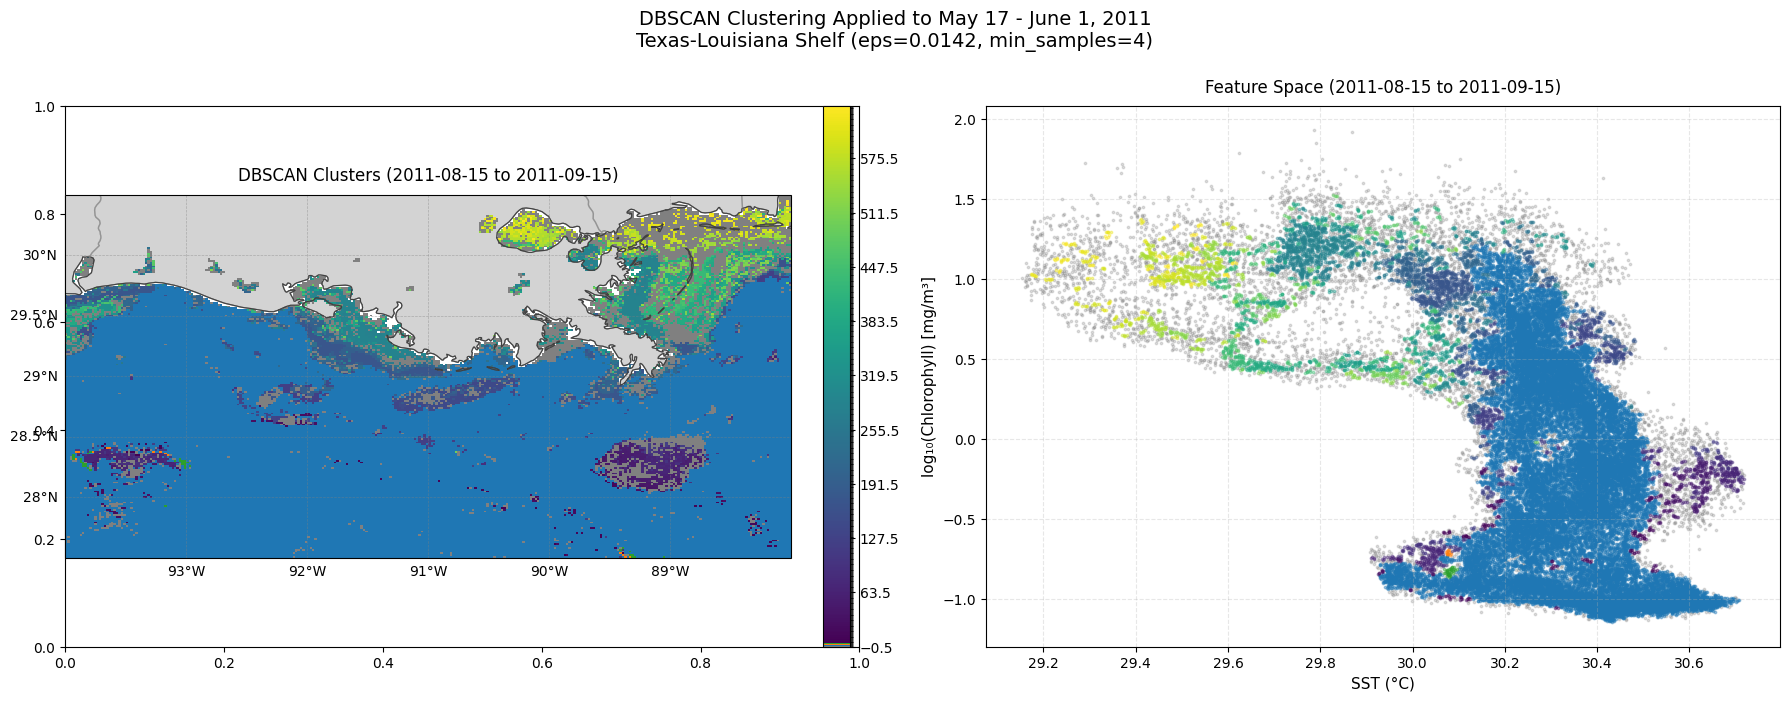


✓ Visualization complete for 2011-08-15 to 2011-09-15


In [62]:
# Visualize the example period with cluster assignments
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Prepare cluster plot map and colormap
plot_map_ex = np.full_like(cluster_map_ex, np.nan)
unique_labels_ex = sorted(set(labels_ex))
cluster_labels_ex = [l for l in unique_labels_ex if l != -1]
cluster_labels_sorted_ex = sorted(cluster_labels_ex)

# Create colormap for this example (same as Section 9)
from matplotlib.colors import ListedColormap, BoundaryNorm, rgb2hex

palette_ex = ['#1f77b4', '#ff7f0e', '#2ca02c']
if len(cluster_labels_sorted_ex) > len(palette_ex):
    extra = plt.cm.viridis(np.linspace(0, 1, len(cluster_labels_sorted_ex) - len(palette_ex)))
    extra_hex = [rgb2hex(c) for c in extra]
    palette_ex = palette_ex + extra_hex

cmap_colors_ex = ['#808080'] + palette_ex
cmap_ex = ListedColormap(cmap_colors_ex)
bounds_ex = np.arange(0, len(cluster_labels_sorted_ex) + 2) - 0.5
norm_ex = BoundaryNorm(bounds_ex, cmap_ex.N)

# Build colors_map for feature space plot
colors_map_ex = {-1: '#808080'}
for i, cl in enumerate(cluster_labels_sorted_ex):
    colors_map_ex[cl] = palette_ex[i]

if len(cluster_labels_sorted_ex) > 0:
    plot_map_ex[valid_mask_ex] = np.where(
        labels_ex == -1, 
        0, 
        np.array([cluster_labels_sorted_ex.index(l) + 1 if l in cluster_labels_sorted_ex else 0 
                  for l in labels_ex])
    )

# 1. Cluster Map
ax = axes[0]
ax = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
cluster_plot = ax.pcolormesh(lon_edges, lat_edges, plot_map_ex,
                             cmap=cmap_ex, norm=norm_ex, shading='auto',
                             transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
# Colorbar without labels
plt.colorbar(cluster_plot, ax=ax, fraction=0.046, pad=0.04)
ax.set_title(f'DBSCAN Clusters ({example_start} to {example_end})', fontsize=12, pad=10)

# 2. Feature space scatter
ax = axes[1]

for cl in unique_labels_ex:
    mask = labels_ex == cl
    color = colors_map_ex.get(cl, '#000000')
    # No label text in scatter plot
    ax.scatter(sst_valid_ex[mask], np.log10(chlor_valid_ex[mask]), 
               alpha=0.4 if cl != -1 else 0.25, s=3, color=color)

ax.set_xlabel('SST (°C)', fontsize=11)
ax.set_ylabel('log₁₀(Chlorophyll) [mg/m³]', fontsize=11)
ax.set_title(f'Feature Space ({example_start} to {example_end})', fontsize=12, pad=10)
ax.grid(True, alpha=0.3, linestyle='--')

plt.suptitle(f'DBSCAN Clustering Applied to May 17 - June 1, 2011\n' +
             f'Texas-Louisiana Shelf (eps={eps:.4f}, min_samples={min_samples})',
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n✓ Visualization complete for {example_start} to {example_end}")

In [ ]:
# Print statistics for this example period
print("=" * 80)
print(f"CLUSTER STATISTICS FOR {example_start.upper()} TO {example_end.upper()}")
print("=" * 80)

for label in sorted(set(labels_ex)):
    mask = labels_ex == label
    sst_cluster_ex = sst_valid_ex[mask]
    chlor_cluster_ex = chlor_valid_ex[mask]
    
    if label == -1:
        print(f"\n⚪ Noise Points:")
    else:
        print(f"\n🔵 Cluster {label}:")
    
    print(f"  Pixels: {mask.sum():,} ({100*mask.sum()/len(mask):.1f}%)")
    print(f"  SST: {sst_cluster_ex.mean():.2f} ± {sst_cluster_ex.std():.2f} °C")
    print(f"       Range: [{sst_cluster_ex.min():.2f}, {sst_cluster_ex.max():.2f}] °C")
    print(f"  Chlorophyll: {chlor_cluster_ex.mean():.6f} ± {chlor_cluster_ex.std():.6f} mg/m³")
    print(f"               Range: [{chlor_cluster_ex.min():.6f}, {chlor_cluster_ex.max():.6f}] mg/m³")

print("\n" + "=" * 80)